# CS420 – Artificial Intelligence  
## Project 2: Machine Learning  
### Fashion-MNIST Dataset Analysis

---

**Objective.** This notebook follows the official Project 2 specification and implements supervised learning experiments using **Decision Tree** and **Neural Network (MLP)** classifiers in **scikit-learn**.

**Dataset.** Fashion-MNIST (28×28 grayscale images; 10 classes; 70,000 total samples).

**Reproducibility.** Random seeds are fixed where applicable. All visualizations are included in the notebook, while statistical results and interpretation can be summarized in the report.

Public references: Zalando Research Fashion-MNIST repository and OpenML dataset page.


## 1. Dataset Preparation

This section:
1. Loads the dataset (features and labels).
2. Shuffles and splits the *provided training portion* into:
   - **Training set (80%)** for model fitting
   - **Validation set (20%)** for hyperparameter tuning
   using a **stratified strategy** to preserve class proportions.
3. Keeps the test set **unchanged** for final evaluation only.
4. Visualizes class distributions to verify correct preparation.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split


In [7]:
from sklearn.datasets import fetch_openml

# Load Fashion-MNIST from OpenML (flattened to 784 features)
X, y = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

# Normalize pixel values to [0, 1]
X = X / 255.0

n_classes = 10

# Create a 60k/10k split via stratified sampling (equivalent proportions)
feature_train_full, feature_test, label_train_full, label_test = train_test_split(
    X, y, test_size=1/7, stratify=y, random_state=42
)

# Stratified split train/validation (80/20)
feature_train, feature_val, label_train, label_val = train_test_split(
    feature_train_full, label_train_full, test_size=0.2, stratify=label_train_full, random_state=42
)

print("Training set:", feature_train.shape)
print("Validation set:", feature_val.shape)
print("Test set:", feature_test.shape)


Training set: (48000, 784)
Validation set: (12000, 784)
Test set: (10000, 784)


### Visualize a small grid of training images

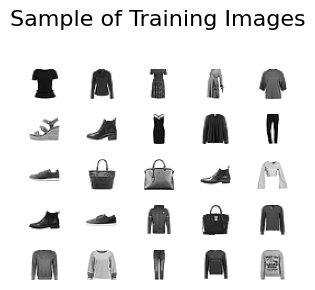

In [8]:
import matplotlib.pyplot as plt

# Create a figure and a 5x5 grid of subplots
fig, axes = plt.subplots(5, 5, figsize=(3, 3))
axes = axes.flatten()

# Display the first 25 training images
for i in range(25):
    # Reshape the 784-pixel image to 28x28 for display
    image = feature_train[i].reshape(28, 28)
    axes[i].imshow(image, cmap='gray_r') # 'gray_r' for white background, black digits
    axes[i].axis('off') # Hide axes

plt.suptitle("Sample of Training Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Class Distribution Visualization

The following plots illustrate the class distributions across the original dataset, training set, validation set, and test set.

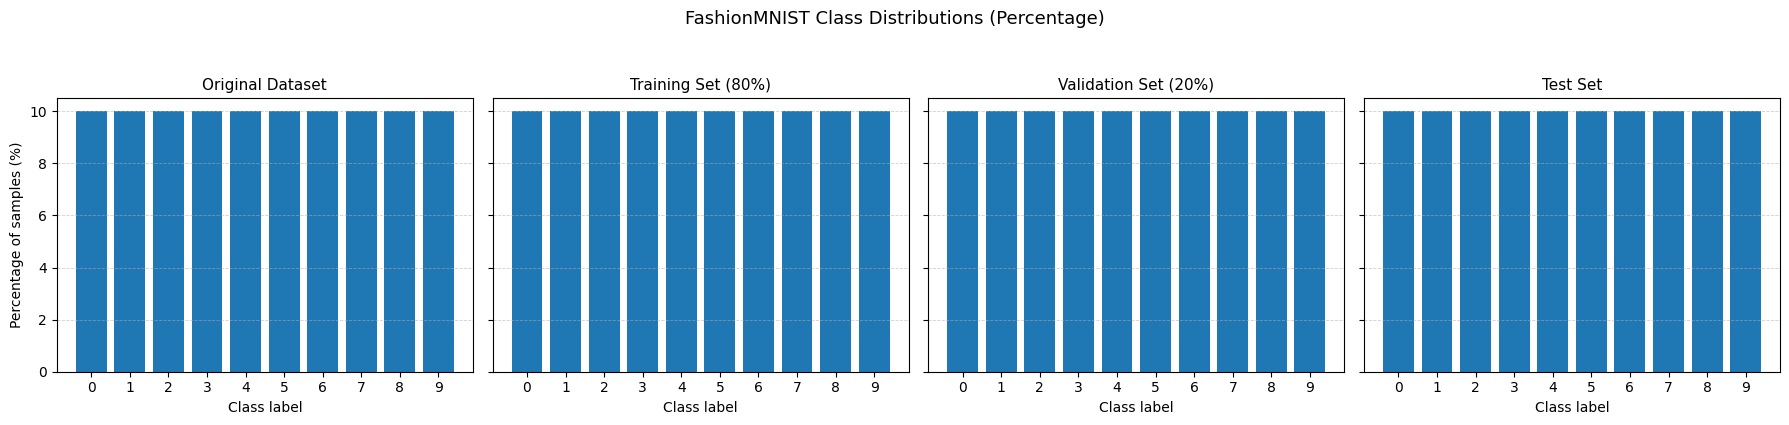

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def plot_distribution_percent(ax, labels, title, n_classes=10, y_max=12):
    classes = np.arange(n_classes)
    c = Counter(labels)
    counts = np.array([c.get(k, 0) for k in classes], dtype=float)
    percents = counts / counts.sum() * 100.0

    ax.bar(classes, percents, width=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Class label")
    ax.set_xticks(classes)
    ax.set_ylim(0, y_max)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# Data + titles
label_sets = [y, label_train, label_val, label_test]
titles = ["Original Dataset", "Training Set (80%)", "Validation Set (20%)", "Test Set"]

# compute a shared y-limit (nice-looking)
all_percents_max = 0
for labels in label_sets:
    c = Counter(labels)
    counts = np.array([c.get(k, 0) for k in range(10)], dtype=float)
    percents = counts / counts.sum() * 100.0
    all_percents_max = max(all_percents_max, percents.max())
y_max = float(np.ceil((all_percents_max + 0.5) * 2) / 2)  # round up to 0.5%

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, labels, title in zip(axes, label_sets, titles):
    plot_distribution_percent(ax, labels, title, n_classes=10, y_max=y_max)

axes[0].set_ylabel("Percentage of samples (%)")
fig.suptitle("FashionMNIST Class Distributions (Percentage)", fontsize=13, y=1.05)
fig.tight_layout()
plt.show()

## 2. Decision Tree Classifier

**Decision Tree with Information Gain**

- We use entropy as the splitting criterion, which corresponds to Information Gain.

- Information Gain represents the expected reduction in entropy after splitting the data on a feature.

- Decision Trees trained with Information Gain tend to create splits that most reduce class uncertainty at each node.


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(feature_train, label_train)

dt_val_pred = dt.predict(feature_val)
dt_val_acc = accuracy_score(label_val, dt_val_pred)
print(f"Decision Tree validation accuracy: {dt_val_acc:.4f}")


Decision Tree validation accuracy: 0.8025


### Decision Tree Visualization (Graphviz)

Because these datasets are high-dimensional, a full tree is typically too large to inspect.  
For clarity, the visualization below limits the displayed depth.


In [11]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,
    out_file=None,
    max_depth=None,
    filled=True,
    rounded=True,
)

graphviz.Source(dot_data)

Output hidden; open in https://colab.research.google.com to view.

In [12]:
src = graphviz.Source(dot_data)
svg_path = src.render(filename="fashionmnist_decision_tree", format="svg", cleanup=True)
print("Saved to:", svg_path)


Saved to: fashionmnist_decision_tree.svg


## 3. Hyperparameter Tuning (Decision Tree)

Hyperparameters tuned on the validation set:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

A compact grid is used to keep runtime reasonable while still exploring model capacity and regularization.

The validation accuracy saturates after a certain tree depth, indicating that increasing model complexity does not further improve generalization.


In [13]:
best_acc = -1.0
best_params = None
best_model = None

max_depth_list = [10, 20, 30]
min_split_list = [2, 20, 100]
min_leaf_list  = [1, 5]

for max_depth in max_depth_list:
    for min_split in min_split_list:
        for min_leaf in min_leaf_list:
            model = DecisionTreeClassifier(
                criterion="entropy",
                max_depth=max_depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )
            model.fit(feature_train, label_train)
            acc = accuracy_score(label_val, model.predict(feature_val))

            if acc > best_acc:
                best_acc = acc
                best_params = (max_depth, min_split, min_leaf)
                best_model = model

print(f"Best validation accuracy: {best_acc:.4f}")
print("Best parameters (max_depth, min_samples_split, min_samples_leaf):", best_params)


Best validation accuracy: 0.8109
Best parameters (max_depth, min_samples_split, min_samples_leaf): (20, 100, 5)


## 4. Neural Network Classifier

An MLP classifier is trained with:
- **Architecture:** one hidden layer
- **Hidden units:** 128
- **Activation:** ReLU
- **Optimizer:** Adam
- **Early stopping:** enabled to improve training stability


In [14]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

mlp.fit(feature_train, label_train)

mlp_val_pred = mlp.predict(feature_val)
mlp_val_acc = accuracy_score(label_val, mlp_val_pred)

print(f"MLP validation accuracy: {mlp_val_acc:.4f}")
print("Training iterations used:", mlp.n_iter_)


MLP validation accuracy: 0.8961
Training iterations used: 43


## 5. Performance Evaluation and Comparison (Test Set)

The test set is used **only once** for the final evaluation of:
- the **best decision tree** selected by validation accuracy, and
- the **MLP** model.

Evaluation outputs:
- `classification_report`
- `confusion_matrix` (visualized side-by-side)


In [15]:

from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, HTML

# Decision Tree (best model)
best_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=best_params[0],
    min_samples_split=best_params[1],
    min_samples_leaf=best_params[2],
    random_state=42
)
best_dt.fit(feature_train, label_train)

dt_test_pred = best_dt.predict(feature_test)
mlp_test_pred = mlp.predict(feature_test)

dt_text  = classification_report(label_test, dt_test_pred, digits=4, zero_division=0)
mlp_text = classification_report(label_test, mlp_test_pred, digits=4, zero_division=0)

display(HTML(f"""
<div style="display:flex; gap:24px;">
  <div style="flex:1;">
    <h4>Decision Tree — Classification Report</h4>
    <pre>{dt_text}</pre>
  </div>
  <div style="flex:1;">
    <h4>Neural Network (MLP) — Classification Report</h4>
    <pre>{mlp_text}</pre>
  </div>
</div>
"""))

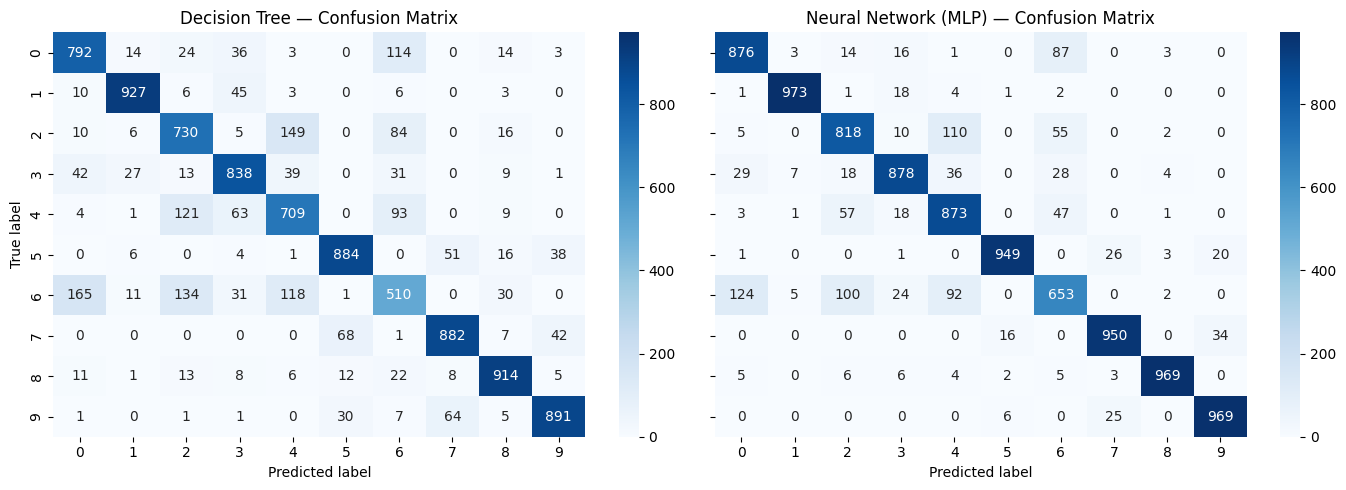

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_dt  = confusion_matrix(label_test, dt_test_pred)
cm_mlp = confusion_matrix(label_test, mlp_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Use the same color scale for both plots
vmax = max(cm_dt.max(), cm_mlp.max())
labels = list(range(10))

sns.heatmap(
    cm_dt, ax=axes[0], cmap="Blues",
    annot=True, fmt="d",
    xticklabels=labels, yticklabels=labels,
    vmin=0, vmax=vmax
)
axes[0].set_title("Decision Tree — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(
    cm_mlp, ax=axes[1], cmap="Blues",
    annot=True, fmt="d",
    xticklabels=labels, yticklabels=labels,
    vmin=0, vmax=vmax
)
axes[1].set_title("Neural Network (MLP) — Confusion Matrix")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("")

fig.tight_layout()
plt.show()


**Insight:**

- The Multilayer Perceptron significantly outperforms the Decision Tree on Fashion-MNIST.

- Although the overall accuracy is lower than MNIST,
the neural network demonstrates better generalization on this more challenging dataset,
highlighting its advantage for high-dimensional image data.

## Insight

- Fashion-MNIST highlights the limitations of tree-based models on complex image data
and reinforces the effectiveness of neural networks for learning distributed representations.
However, it also shows that increased model capacity alone cannot fully resolve
ambiguities inherent in the data.

- Compared to MNIST, Fashion-MNIST is a more challenging classification task.
While digit images have clear and consistent stroke patterns,
clothing items exhibit higher intra-class variation and inter-class similarity.